# Stage 2 — 2D Stokes flow on a staggered grid

The solid ice deforms as an extremely viscous fluid, so inertia is negligible and momentum reduces to the Stokes equations
(z up, gravity along −z):

$$\frac{\partial \sigma_{xx}}{\partial x} + \frac{\partial \sigma_{xz}}{\partial z} - \frac{\partial P}{\partial x} = 0, \qquad
\frac{\partial \sigma_{zx}}{\partial x} + \frac{\partial \sigma_{zz}}{\partial z} - \frac{\partial P}{\partial z} = \rho g, \qquad
\frac{\partial v_x}{\partial x} + \frac{\partial v_z}{\partial z} = 0$$

with deviatoric stresses σ_xx = 2η ∂v_x/∂x, σ_zz = 2η ∂v_z/∂z, σ_xz = η(∂v_x/∂z + ∂v_z/∂x).

**Staggered grid** (Harlow & Welch 1965; Gerya 2019): P sits at cell centres, v_x on vertical cell faces, v_z on horizontal faces,
and the shear viscosity at cell corners. Every derivative then becomes a centred difference between neighbours, which is
second-order accurate and avoids the checkerboard pressure modes that a collocated grid produces.

Boundaries: **free slip** on all walls (no flow through them, no shear stress along them).
All unknowns go into one sparse linear system, solved directly.

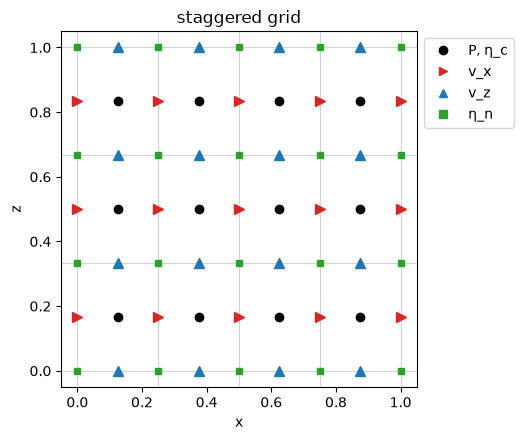

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

class Grid:
    """Staggered grid on [0, L] x [0, H], z positive up.
    vx    at vertical faces   (x = i dx,       z = (j+½) dz): shape (nz, nx+1)
    vz    at horizontal faces (x = (i+½) dx,   z = j dz):     shape (nz+1, nx)
    P, eta_c at cell centres  (x = (i+½) dx,   z = (j+½) dz): shape (nz, nx)
    eta_n at cell corners     (x = i dx,       z = j dz):     shape (nz+1, nx+1)"""
    def __init__(self, nx, nz, L=1.0, H=1.0):
        self.nx, self.nz, self.L, self.H = nx, nz, L, H
        self.dx, self.dz = L / nx, H / nz
        self.xc = (np.arange(nx) + 0.5) * self.dx
        self.zc = (np.arange(nz) + 0.5) * self.dz
        self.xn = np.arange(nx + 1) * self.dx
        self.zn = np.arange(nz + 1) * self.dz
        self.n_vx, self.n_vz, self.n_p = nz * (nx + 1), (nz + 1) * nx, nz * nx

    # position of each unknown in the global solution vector [vx..., vz..., P...]
    def ivx(self, j, i): return j * (self.nx + 1) + i
    def ivz(self, j, i): return self.n_vx + j * self.nx + i
    def ip(self, j, i):  return self.n_vx + self.n_vz + j * self.nx + i

# picture of a 4 x 3 grid
g = Grid(4, 3)
fig, ax = plt.subplots(figsize=(6, 4.5))
for x in g.xn: ax.axvline(x, c="lightgrey", lw=0.8)
for z in g.zn: ax.axhline(z, c="lightgrey", lw=0.8)
Xc, Zc = np.meshgrid(g.xc, g.zc); ax.plot(Xc, Zc, "ko", ms=6)
Xx, Zx = np.meshgrid(g.xn, g.zc); ax.plot(Xx, Zx, ">", c="tab:red", ms=7)
Xz, Zz = np.meshgrid(g.xc, g.zn); ax.plot(Xz, Zz, "^", c="tab:blue", ms=7)
Xn, Zn = np.meshgrid(g.xn, g.zn); ax.plot(Xn, Zn, "s", c="tab:green", ms=4)
ax.legend(handles=[plt.Line2D([], [], ls="", marker=m, c=c, label=l) for m, c, l in
                   [("o", "k", "P, η_c"), (">", "tab:red", "v_x"), ("^", "tab:blue", "v_z"), ("s", "tab:green", "η_n")]],
          loc="upper left", bbox_to_anchor=(1, 1))
ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("z"); ax.set_title("staggered grid")
plt.tight_layout(); plt.show()

In [2]:
def stokes_system(g, eta_c, eta_n, rho_vz, grav=1.0):
    """Free-slip box: div(sigma) - grad P = rho g e_z,  div v = 0  (gravity points along -z).
    eta_c (nz, nx), eta_n (nz+1, nx+1): viscosity at centres and corners.
    rho_vz (nz+1, nx): density at vz points. Returns the sparse matrix A and right-hand side b."""
    nx, nz, dx, dz = g.nx, g.nz, g.dx, g.dz
    rows, cols, vals = [], [], []
    b = np.zeros(g.n_vx + g.n_vz + g.n_p)
    def add(r, c, v):
        rows.append(r); cols.append(c); vals.append(v)

    # x-momentum at vx points
    for j in range(nz):
        for i in range(nx + 1):
            r = g.ivx(j, i)
            if i == 0 or i == nx:                     # side walls: vx = 0
                add(r, r, 1.0); continue
            # d(sigma_xx)/dx, sigma_xx = 2 eta_c dvx/dx at centres (j,i) and (j,i-1)
            eR, eL = eta_c[j, i], eta_c[j, i - 1]
            add(r, g.ivx(j, i + 1), 2 * eR / dx**2)
            add(r, g.ivx(j, i),    -2 * (eR + eL) / dx**2)
            add(r, g.ivx(j, i - 1), 2 * eL / dx**2)
            # d(sigma_xz)/dz, sigma_xz = eta_n (dvx/dz + dvz/dx) at corners (j+1,i) and (j,i)
            if j + 1 < nz:                            # top corner (sigma_xz = 0 on the top wall: free slip)
                eT = eta_n[j + 1, i]
                add(r, g.ivx(j + 1, i), eT / dz**2)
                add(r, g.ivx(j, i),    -eT / dz**2)
                add(r, g.ivz(j + 1, i),     eT / (dx * dz))
                add(r, g.ivz(j + 1, i - 1), -eT / (dx * dz))
            if j > 0:                                 # bottom corner
                eB = eta_n[j, i]
                add(r, g.ivx(j, i),    -eB / dz**2)
                add(r, g.ivx(j - 1, i), eB / dz**2)
                add(r, g.ivz(j, i),     -eB / (dx * dz))
                add(r, g.ivz(j, i - 1),  eB / (dx * dz))
            # -dP/dx
            add(r, g.ip(j, i),     -1.0 / dx)
            add(r, g.ip(j, i - 1),  1.0 / dx)

    # z-momentum at vz points
    for j in range(nz + 1):
        for i in range(nx):
            r = g.ivz(j, i)
            if j == 0 or j == nz:                     # top/bottom walls: vz = 0
                add(r, r, 1.0); continue
            # d(sigma_zz)/dz
            eT, eB = eta_c[j, i], eta_c[j - 1, i]
            add(r, g.ivz(j + 1, i), 2 * eT / dz**2)
            add(r, g.ivz(j, i),    -2 * (eT + eB) / dz**2)
            add(r, g.ivz(j - 1, i), 2 * eB / dz**2)
            # d(sigma_zx)/dx at corners (j,i+1) and (j,i)
            if i + 1 < nx:                            # right corner (zero on the side wall: free slip)
                eR = eta_n[j, i + 1]
                add(r, g.ivz(j, i + 1), eR / dx**2)
                add(r, g.ivz(j, i),    -eR / dx**2)
                add(r, g.ivx(j, i + 1),     eR / (dx * dz))
                add(r, g.ivx(j - 1, i + 1), -eR / (dx * dz))
            if i > 0:                                 # left corner
                eL = eta_n[j, i]
                add(r, g.ivz(j, i),    -eL / dx**2)
                add(r, g.ivz(j, i - 1), eL / dx**2)
                add(r, g.ivx(j, i),     -eL / (dx * dz))
                add(r, g.ivx(j - 1, i),  eL / (dx * dz))
            # -dP/dz
            add(r, g.ip(j, i),     -1.0 / dz)
            add(r, g.ip(j - 1, i),  1.0 / dz)
            b[r] = rho_vz[j, i] * grav

    # continuity at centres; one row replaced by P = 0 (pressure is only defined up to a constant)
    for j in range(nz):
        for i in range(nx):
            r = g.ip(j, i)
            if i == 0 and j == 0:
                add(r, r, 1.0); continue
            add(r, g.ivx(j, i + 1),  1.0 / dx)
            add(r, g.ivx(j, i),     -1.0 / dx)
            add(r, g.ivz(j + 1, i),  1.0 / dz)
            add(r, g.ivz(j, i),     -1.0 / dz)

    A = sp.csc_matrix((vals, (rows, cols)), shape=(b.size, b.size))
    return A, b


def unpack(g, s):
    """Split the solution vector into vx, vz, P arrays."""
    vx = s[:g.n_vx].reshape(g.nz, g.nx + 1)
    vz = s[g.n_vx:g.n_vx + g.n_vz].reshape(g.nz + 1, g.nx)
    P = s[g.n_vx + g.n_vz:].reshape(g.nz, g.nx)
    return vx, vz, P


def solve_stokes(g, eta_c, eta_n, rho_vz, grav=1.0):
    """Assemble and solve in one go (used by the analytic benchmark in cell 4)."""
    A, b = stokes_system(g, eta_c, eta_n, rho_vz, grav)
    return unpack(g, spsolve(A, b))

## Benchmark — flow driven by a sinusoidal density anomaly

For constant η = 1 and ρ = cos(πx) sin(πz) in a unit box, taking the curl of the momentum equation gives η∇⁴ψ = −g ∂ρ/∂x.
With free slip, the exact solution is a single convection cell:

$$\psi = A \sin(\pi x)\sin(\pi z),\quad A = \frac{\pi}{(2\pi^2)^2},\quad v_x = \partial_z\psi,\ v_z = -\partial_x\psi$$


  16²: relative velocity error 3.22e-03, max |div v| 2.8e-13
  32²: relative velocity error 8.04e-04, max |div v| 3.0e-12
  64²: relative velocity error 2.01e-04, max |div v| 1.3e-11
 128²: relative velocity error 5.02e-05, max |div v| 1.8e-09
convergence order: [2. 2. 2.]


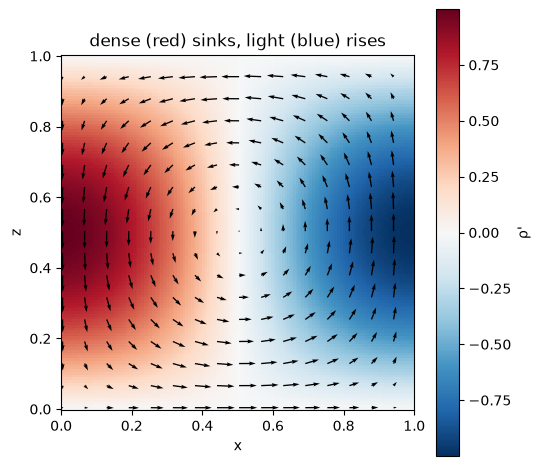

In [3]:
errors = []
for n in (16, 32, 64, 128):
    g = Grid(n, n)
    k = np.pi
    Xz, Zz = np.meshgrid(g.xc, g.zn)                 # vz points
    Xx, Zx = np.meshgrid(g.xn, g.zc)                 # vx points
    rho = np.cos(k * Xz) * np.sin(k * Zz)
    vx, vz, P = solve_stokes(g, np.ones((n, n)), np.ones((n + 1, n + 1)), rho)

    A = k / (2 * k**2) ** 2
    vx_exact = A * k * np.sin(k * Xx) * np.cos(k * Zx)
    vz_exact = -A * k * np.cos(k * Xz) * np.sin(k * Zz)
    err = max(np.abs(vx - vx_exact).max(), np.abs(vz - vz_exact).max()) / np.abs(vz_exact).max()
    div = np.abs((vx[:, 1:] - vx[:, :-1]) / g.dx + (vz[1:] - vz[:-1]) / g.dz).max()
    errors.append(err)
    print(f"{n:4d}²: relative velocity error {err:.2e}, max |div v| {div:.1e}")
print("convergence order:", np.round(np.log2(np.array(errors[:-1]) / np.array(errors[1:])), 2))

# velocity field on the finest grid, interpolated to cell centres
vxc = 0.5 * (vx[:, 1:] + vx[:, :-1]); vzc = 0.5 * (vz[1:] + vz[:-1])
Xc, Zc = np.meshgrid(g.xc, g.zc)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.pcolormesh(g.xc, g.zn, rho, cmap="RdBu_r", shading="auto")
s = 8
ax.quiver(Xc[::s, ::s], Zc[::s, ::s], vxc[::s, ::s], vzc[::s, ::s])
fig.colorbar(im, label="ρ'"); ax.set_aspect("equal"); ax.set_xlabel("x"); ax.set_ylabel("z")
ax.set_title("dense (red) sinks, light (blue) rises")
plt.tight_layout(); plt.show()

## Stage 2b — Thermal convection: the Blankenbach benchmark

Boussinesq, non-dimensional (lengths in H, time in H²/κ, temperature in ΔT), constant viscosity:

$$-\nabla P + \nabla^2 \mathbf v = -Ra\,T\,\hat{\mathbf z}, \qquad \nabla\cdot\mathbf v = 0, \qquad
\frac{\partial T}{\partial t} + \nabla\cdot(\mathbf v T) = \nabla^2 T, \qquad Ra = \frac{\rho_0 \alpha \Delta T g H^3}{\eta \kappa}$$

So the Stokes solver from before gets density ρ' = −Ra·T. Hot means light.
Box: unit square, T = 1 at the bottom, T = 0 at the top, insulating sides, free slip everywhere.

**Blankenbach et al. (1989), case 1a (Ra = 10⁴):** steady state with Nu = 4.884409 and v_rms = 42.864947.
Nu is the non-dimensional heat flux through the top; v_rms is the root-mean-square velocity.

In [4]:
from scipy.sparse.linalg import splu

def T_ghost(T, T_bot=1.0, T_top=0.0):
    """T at cell centres padded with ghost cells: fixed T at bottom and top, insulating sides."""
    Tg = np.pad(T, 1)
    Tg[1:-1, 0], Tg[1:-1, -1] = T[:, 0], T[:, -1]       # dT/dx = 0 on the side walls
    Tg[0, 1:-1] = 2 * T_bot - T[0]                        # wall value = mean of ghost and first cell
    Tg[-1, 1:-1] = 2 * T_top - T[-1]
    return Tg

def dTdt(T, vx, vz, g):
    """-div(v T) + laplacian(T): conservative central differences, velocities on cell faces."""
    Tg = T_ghost(T)
    Tfx = 0.5 * (Tg[1:-1, 1:] + Tg[1:-1, :-1])          # T on vertical faces
    Tfz = 0.5 * (Tg[1:, 1:-1] + Tg[:-1, 1:-1])          # T on horizontal faces
    adv = (vx[:, 1:] * Tfx[:, 1:] - vx[:, :-1] * Tfx[:, :-1]) / g.dx \
        + (vz[1:] * Tfz[1:] - vz[:-1] * Tfz[:-1]) / g.dz
    lap = (Tg[1:-1, 2:] - 2 * T + Tg[1:-1, :-2]) / g.dx**2 + (Tg[2:, 1:-1] - 2 * T + Tg[:-2, 1:-1]) / g.dz**2
    return -adv + lap

def nusselt(T, g):
    """Mean heat flux through the top wall (T = 0), second-order one-sided gradient."""
    dTdz = (8 * 0.0 - 9 * T[-1] + T[-2]) / (3 * g.dz)
    return -dTdz.mean()

def vrms(vx, vz):
    vxc = 0.5 * (vx[:, 1:] + vx[:, :-1]); vzc = 0.5 * (vz[1:] + vz[:-1])
    return np.sqrt(np.mean(vxc**2 + vzc**2))

def convect(n, Ra, t_end=0.6, cfl=0.5):
    g = Grid(n, n)
    A, _ = stokes_system(g, np.ones((n, n)), np.ones((n + 1, n + 1)), np.zeros((n + 1, n)))
    lu = splu(A)                                          # constant viscosity: factorise ONCE
    Xc, Zc = np.meshgrid(g.xc, g.zc)
    T = 1 - Zc + 0.01 * np.cos(np.pi * Xc) * np.sin(np.pi * Zc)   # conductive profile + small kick
    b = np.zeros(A.shape[0])
    t, hist = 0.0, []
    while t < t_end:
        # Stokes: buoyancy rho' = -Ra T at the vz points
        Tg = T_ghost(T)
        bz = -Ra * 0.5 * (Tg[1:, 1:-1] + Tg[:-1, 1:-1])
        bz[0], bz[-1] = 0.0, 0.0                          # boundary rows (vz = 0)
        b[g.n_vx:g.n_vx + g.n_vz] = bz.ravel()
        vx, vz, _ = unpack(g, lu.solve(b))
        # energy: Heun (RK2) step with the velocity held fixed
        dt = min(cfl * g.dx / max(np.abs(vx).max(), np.abs(vz).max(), 1e-12), 0.2 * g.dx**2)
        k1 = dTdt(T, vx, vz, g)
        T = T + 0.5 * dt * (k1 + dTdt(T + dt * k1, vx, vz, g))
        t += dt
        hist.append((t, nusselt(T, g), vrms(vx, vz)))
    return g, T, vx, vz, np.array(hist)

 16²: Nu = 5.0963, vrms = 42.024   (1289 steps, 0.2 s)
 32²: Nu = 4.9552, vrms = 42.653   (3092 steps, 1.0 s)
 64²: Nu = 4.9035, vrms = 42.812   (12289 steps, 18.3 s)

extrapolated:   Nu = 4.8863  (Blankenbach 4.8844, +0.04 %)
                vrms = 42.865  (Blankenbach 42.865, -0.000 %)


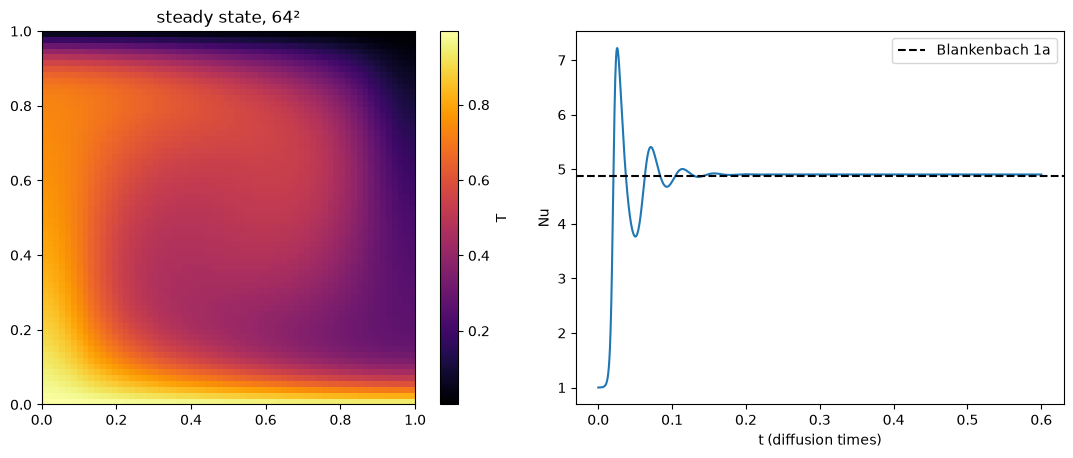

In [5]:
import time
NU_BB, VRMS_BB = 4.884409, 42.864947
res = {}
for n in (16, 32, 64):
    t0 = time.time()
    g, T, vx, vz, hist = convect(n, Ra=1e4)
    res[n] = hist[-1, 1:]
    print(f"{n:3d}²: Nu = {res[n][0]:.4f}, vrms = {res[n][1]:.3f}   ({len(hist)} steps, {time.time()-t0:.1f} s)")

# Richardson extrapolation, assuming second-order convergence
nu_ex = (4 * res[64][0] - res[32][0]) / 3
vr_ex = (4 * res[64][1] - res[32][1]) / 3
print(f"\nextrapolated:   Nu = {nu_ex:.4f}  (Blankenbach {NU_BB:.4f}, {100*(nu_ex/NU_BB-1):+.2f} %)")
print(f"                vrms = {vr_ex:.3f}  (Blankenbach {VRMS_BB:.3f}, {100*(vr_ex/VRMS_BB-1):+.3f} %)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
im = ax[0].pcolormesh(g.xc, g.zc, T, cmap="inferno", shading="auto")
fig.colorbar(im, ax=ax[0], label="T"); ax[0].set_aspect("equal"); ax[0].set_title(f"steady state, {n}²")
ax[1].plot(hist[:, 0], hist[:, 1]); ax[1].axhline(NU_BB, ls="--", c="k", label="Blankenbach 1a")
ax[1].set_xlabel("t (diffusion times)"); ax[1].set_ylabel("Nu"); ax[1].legend()
plt.tight_layout(); plt.show()

## Stage 2c — Temperature-dependent viscosity

Ice viscosity drops by orders of magnitude from the cold surface to the warm base. Benchmark:
**Blankenbach et al. (1989) case 2a**: η = exp(−b T) with b = ln(1000), so a factor 10³ between top and bottom, Ra = 10⁴
(defined with the cold-end viscosity). Reference: Nu = 10.0660, v_rms = 480.4334.

Two changes from 2b:
1. **The Stokes matrix depends on T,** so it has to be rebuilt every iteration. The loop assembly is too slow for that, so it gets vectorised
   (same matrix, built from index arrays). We check that it is *identical* to the loop version.
2. **Solve for the steady state directly** (Picard iteration) instead of time-stepping:
   Stokes with the current η → steady energy equation with that velocity → relax → repeat.
   Much faster for steady benchmarks; time-dependent runs come back later, for the ice shell.

In [6]:
def stokes_matrix_fast(g, eta_c, eta_n):
    """Vectorised assembly of exactly the same matrix as stokes_system (no Python loops over cells)."""
    nx, nz, dx, dz = g.nx, g.nz, g.dx, g.dz
    R, C, V = [], [], []
    def put(r, c, v):
        r, c, v = np.broadcast_arrays(r, c, v)
        R.append(r.ravel()); C.append(c.ravel()); V.append(np.asarray(v, float).ravel())
    ivx = lambda j, i: j * (nx + 1) + i
    ivz = lambda j, i: g.n_vx + j * nx + i
    ip  = lambda j, i: g.n_vx + g.n_vz + j * nx + i

    # x-momentum
    J, I = np.meshgrid(np.arange(nz), np.arange(nx + 1), indexing="ij")
    wall = (I == 0) | (I == nx)
    put(ivx(J[wall], I[wall]), ivx(J[wall], I[wall]), 1.0)
    j, i = J[~wall], I[~wall]; r = ivx(j, i)
    eR, eL = eta_c[j, i], eta_c[j, i - 1]
    put(r, ivx(j, i + 1), 2 * eR / dx**2); put(r, r, -2 * (eR + eL) / dx**2); put(r, ivx(j, i - 1), 2 * eL / dx**2)
    m = j + 1 < nz; jj, ii, rr = j[m], i[m], r[m]; eT = eta_n[jj + 1, ii]
    put(rr, ivx(jj + 1, ii), eT / dz**2); put(rr, rr, -eT / dz**2)
    put(rr, ivz(jj + 1, ii), eT / (dx * dz)); put(rr, ivz(jj + 1, ii - 1), -eT / (dx * dz))
    m = j > 0; jj, ii, rr = j[m], i[m], r[m]; eB = eta_n[jj, ii]
    put(rr, rr, -eB / dz**2); put(rr, ivx(jj - 1, ii), eB / dz**2)
    put(rr, ivz(jj, ii), -eB / (dx * dz)); put(rr, ivz(jj, ii - 1), eB / (dx * dz))
    put(r, ip(j, i), -1.0 / dx); put(r, ip(j, i - 1), 1.0 / dx)

    # z-momentum
    J, I = np.meshgrid(np.arange(nz + 1), np.arange(nx), indexing="ij")
    wall = (J == 0) | (J == nz)
    put(ivz(J[wall], I[wall]), ivz(J[wall], I[wall]), 1.0)
    j, i = J[~wall], I[~wall]; r = ivz(j, i)
    eT, eB = eta_c[j, i], eta_c[j - 1, i]
    put(r, ivz(j + 1, i), 2 * eT / dz**2); put(r, r, -2 * (eT + eB) / dz**2); put(r, ivz(j - 1, i), 2 * eB / dz**2)
    m = i + 1 < nx; jj, ii, rr = j[m], i[m], r[m]; eR = eta_n[jj, ii + 1]
    put(rr, ivz(jj, ii + 1), eR / dx**2); put(rr, rr, -eR / dx**2)
    put(rr, ivx(jj, ii + 1), eR / (dx * dz)); put(rr, ivx(jj - 1, ii + 1), -eR / (dx * dz))
    m = i > 0; jj, ii, rr = j[m], i[m], r[m]; eL = eta_n[jj, ii]
    put(rr, rr, -eL / dx**2); put(rr, ivz(jj, ii - 1), eL / dx**2)
    put(rr, ivx(jj, ii), -eL / (dx * dz)); put(rr, ivx(jj - 1, ii), eL / (dx * dz))
    put(r, ip(j, i), -1.0 / dz); put(r, ip(j - 1, i), 1.0 / dz)

    # continuity (cell (0,0) replaced by P = 0)
    J, I = np.meshgrid(np.arange(nz), np.arange(nx), indexing="ij")
    fix = (J == 0) & (I == 0)
    put(ip(0, 0), ip(0, 0), 1.0)
    j, i = J[~fix], I[~fix]; r = ip(j, i)
    put(r, ivx(j, i + 1), 1 / dx); put(r, ivx(j, i), -1 / dx); put(r, ivz(j + 1, i), 1 / dz); put(r, ivz(j, i), -1 / dz)

    n = g.n_vx + g.n_vz + g.n_p
    return sp.csc_matrix((np.concatenate(V), (np.concatenate(R), np.concatenate(C))), shape=(n, n))

# must be IDENTICAL to the loop version, including with wildly varying viscosity and nx != nz
import time
rng = np.random.default_rng(0)
for nx, nz in ((8, 11), (33, 36), (64, 67)):
    g = Grid(nx, nz)
    eta_c = np.exp(3 * rng.normal(size=(nz, nx))); eta_n = np.exp(3 * rng.normal(size=(nz + 1, nx + 1)))
    A_loop, _ = stokes_system(g, eta_c, eta_n, np.zeros((nz + 1, nx)))
    print(f"{nx}x{nz}: max |A_loop - A_fast| = {abs(A_loop - stokes_matrix_fast(g, eta_c, eta_n)).max()}")
g = Grid(128, 128); e_c, e_n = np.ones((128, 128)), np.ones((129, 129))
t0 = time.time(); stokes_system(g, e_c, e_n, np.zeros((129, 128))); t1 = time.time()
stokes_matrix_fast(g, e_c, e_n); t2 = time.time()
print(f"128²: loop {t1-t0:.3f} s, vectorised {t2-t1:.4f} s  ({(t1-t0)/(t2-t1):.0f}x faster)")

8x11: max |A_loop - A_fast| = 0.0
33x36: max |A_loop - A_fast| = 0.0
64x67: max |A_loop - A_fast| = 0.0
128²: loop 0.177 s, vectorised 0.0077 s  (23x faster)


In [7]:
from scipy.sparse.linalg import spsolve

def energy_steady_matrix(g, vx, vz, T_bot=1.0, T_top=0.0):
    """Steady advection–diffusion  div(v T) − ∇²T = 0  for T at cell centres.
    Central differences (fluxes on cell faces), fixed T at bottom/top via ghost cells, insulating sides."""
    nx, nz, dx, dz = g.nx, g.nz, g.dx, g.dz
    idx = np.arange(nx * nz).reshape(nz, nx)
    R, C, V = [], [], []
    b = np.zeros(nx * nz)
    def put(r, c, v):
        r, c, v = np.broadcast_arrays(r, c, v)
        R.append(r.ravel()); C.append(c.ravel()); V.append(np.asarray(v, float).ravel())

    J, I = np.meshgrid(np.arange(nz), np.arange(nx), indexing="ij")
    # Each interior face between cell P and neighbour N contributes, to row P:
    #   ± u (T_P + T_N) / (2 h)   (advective flux, + for the east/top face, − for west/bottom)
    #   − (T_N − T_P) / h²        (diffusive flux)
    faces = [  # (neighbour offset dj, di, face velocity, sign, grid spacing)
        (0, +1, lambda j, i: vx[j, i + 1], +1, dx),   # east
        (0, -1, lambda j, i: vx[j, i],     -1, dx),   # west
        (+1, 0, lambda j, i: vz[j + 1, i], +1, dz),   # top
        (-1, 0, lambda j, i: vz[j, i],     -1, dz),   # bottom
    ]
    for dj, di, face_v, sgn, h in faces:
        inner = (J + dj >= 0) & (J + dj < nz) & (I + di >= 0) & (I + di < nx)
        j, i = J[inner], I[inner]
        r, u = idx[j, i], face_v(j, i)
        put(r, r, sgn * u / (2 * h) + 1 / h**2)
        put(r, idx[j + dj, i + di], sgn * u / (2 * h) - 1 / h**2)
    # walls: velocity through every wall is 0; side walls are insulating (no flux);
    # top/bottom: ghost T = 2 T_wall − T_P gives a diffusive flux 2 (T_P − T_wall) / dz²
    for row, T_wall in ((0, T_bot), (nz - 1, T_top)):
        r = idx[row]
        put(r, r, 2 / dz**2)
        b[r] += 2 * T_wall / dz**2
    A = sp.csc_matrix((np.concatenate(V), (np.concatenate(R), np.concatenate(C))), shape=(nx * nz, nx * nz))
    return A, b

def viscosity(T, b_visc):
    """eta = exp(−b T) at cell centres, and at corners from the mean T of the four surrounding cells."""
    Tg = T_ghost(T)
    T_corner = 0.25 * (Tg[1:, 1:] + Tg[:-1, 1:] + Tg[1:, :-1] + Tg[:-1, :-1])
    return np.exp(-b_visc * T), np.exp(-b_visc * T_corner)

def steady_convection(n, Ra, b_visc=0.0, relax=0.5, tol=1e-7, max_iter=300):
    """Picard iteration straight to steady state: Stokes with the current viscosity -> steady energy
    equation with that velocity -> relax T -> repeat until T stops changing."""
    g = Grid(n, n)
    Xc, Zc = np.meshgrid(g.xc, g.zc)
    T = 1 - Zc + 0.1 * np.cos(np.pi * Xc) * np.sin(np.pi * Zc)
    for it in range(1, max_iter + 1):
        eta_c, eta_n = viscosity(T, b_visc)
        A = stokes_matrix_fast(g, eta_c, eta_n)
        Tg = T_ghost(T)
        bz = -Ra * 0.5 * (Tg[1:, 1:-1] + Tg[:-1, 1:-1])
        bz[0] = bz[-1] = 0.0
        rhs = np.zeros(A.shape[0]); rhs[g.n_vx:g.n_vx + g.n_vz] = bz.ravel()
        vx, vz, _ = unpack(g, spsolve(A, rhs))
        Ae, be = energy_steady_matrix(g, vx, vz)
        T_new = spsolve(Ae, be).reshape(n, n)
        change = np.abs(T_new - T).max()
        T = relax * T_new + (1 - relax) * T
        if change < tol:
            return g, T, vx, vz, it
    raise RuntimeError(f"no steady state after {max_iter} iterations (last change {change:.1e})")

case 1a  32²: Nu = 4.9552, vrms = 42.653   (25 iterations, 0.3 s)
case 1a  64²: Nu = 4.9035, vrms = 42.812   (25 iterations, 2.1 s)
case 1a 128²: Nu = 4.8893, vrms = 42.852   (25 iterations, 15.8 s)
  extrapolated: Nu = 4.8845 (+0.003 %), vrms = 42.865 (-0.000 %)

case 2a  32²: Nu = 11.6565, vrms = 423.984   (66 iterations, 0.7 s)
case 2a  64²: Nu = 10.3990, vrms = 467.488   (38 iterations, 2.3 s)
case 2a 128²: Nu = 10.1455, vrms = 477.343   (40 iterations, 21.9 s)
  extrapolated: Nu = 10.0610 (-0.050 %), vrms = 480.629 (+0.041 %)



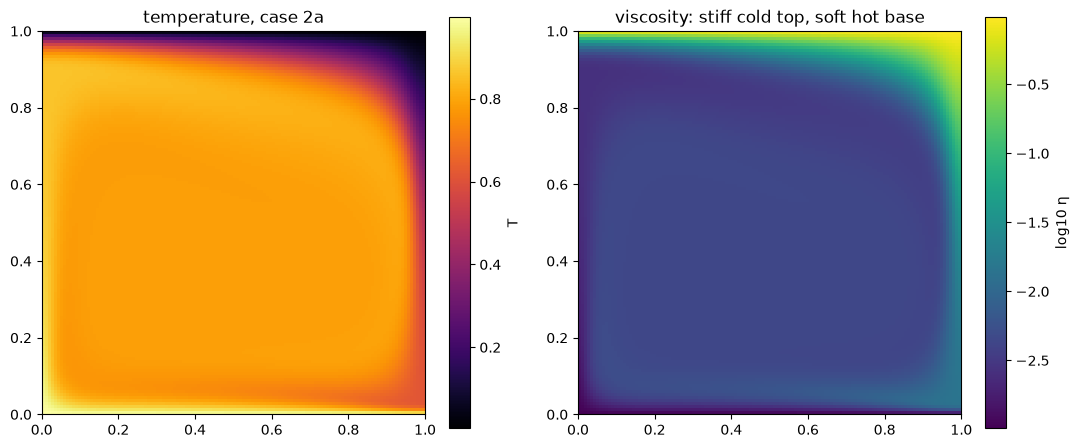

In [8]:
REF = {"1a": (0.0, 4.884409, 42.864947), "2a": (np.log(1000), 10.0660, 480.4334)}
results = {}
for case, (b_visc, nu_ref, vr_ref) in REF.items():
    res = {}
    for n in (32, 64, 128):
        t0 = time.time()
        g, T, vx, vz, iters = steady_convection(n, Ra=1e4, b_visc=b_visc)
        res[n] = (nusselt(T, g), vrms(vx, vz))
        print(f"case {case} {n:3d}²: Nu = {res[n][0]:.4f}, vrms = {res[n][1]:.3f}   ({iters} iterations, {time.time()-t0:.1f} s)")
    nu_ex = (4 * res[128][0] - res[64][0]) / 3
    vr_ex = (4 * res[128][1] - res[64][1]) / 3
    print(f"  extrapolated: Nu = {nu_ex:.4f} ({100*(nu_ex/nu_ref-1):+.3f} %), vrms = {vr_ex:.3f} ({100*(vr_ex/vr_ref-1):+.3f} %)\n")
    results[case] = (g, T, vx, vz)

g, T, vx, vz = results["2a"]
eta_c, _ = viscosity(T, np.log(1000))
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
im = ax[0].pcolormesh(g.xc, g.zc, T, cmap="inferno", shading="auto"); fig.colorbar(im, ax=ax[0], label="T")
im = ax[1].pcolormesh(g.xc, g.zc, np.log10(eta_c), cmap="viridis", shading="auto"); fig.colorbar(im, ax=ax[1], label="log10 η")
for a, t in zip(ax, ("temperature, case 2a", "viscosity: stiff cold top, soft hot base")):
    a.set_aspect("equal"); a.set_title(t)
plt.tight_layout(); plt.show()

## Stage 2d (preview) — Should Ganymede's ice Ih shell convect?

Stagnant-lid onset criterion (Solomatov 1995; as applied to icy shells e.g. by Hammond et al. 2016):

$$Ra = \frac{\rho \alpha g \Delta T D^3}{\kappa\, \eta_b} \quad > \quad Ra_{cr} = 20.9\,\theta^4, \qquad \theta = \frac{Q\,\Delta T}{R\,T_b^2}$$

- η_b: viscosity at the warm base, from diffusion creep η = A d² exp(Q/RT), with A = 8.36×10⁹ (T/250 K) Pa s m⁻² and Q = 59.4 kJ/mol
- D, T_b and g come straight from the Stage 0 self-consistent model
- θ is the Frank-Kamenetskii parameter: how many e-folds the viscosity changes across the shell

In [9]:
from ganymede.thermal import H2OTables, self_consistent_model

R_GAS, Q_ICE = 8.314, 59.4e3
def eta_ice(T, d):
    """Diffusion-creep viscosity of ice Ih [Pa s] for grain size d [m]."""
    return 8.36e9 * (T / 250) * d**2 * np.exp(Q_ICE / (R_GAS * T))

tables = H2OTables()
print(f"{'q':>8} {'shell':>7} {'T_b':>6} {'grain':>7} {'η_b':>9} {'Ra':>9} {'Ra_cr':>9} {'Ra/Ra_cr':>9}  verdict")
for q in (0.005, 0.015, 0.040):
    m = self_consistent_model(q, tables)
    col = m.column; ih = col.phase == 1
    D, T_b, T_s = col.shell, col.T[ih][-1], 110.0
    dT = T_b - T_s
    g = np.interp(m.profile.r[-1] - D / 2, m.profile.r, m.profile.g)    # g at mid-shell
    rho, alpha = 920.0, 1.6e-4
    kappa = (651 / T_b) / (rho * (7.037 * T_b + 185))                    # k(T) / (rho cp(T)) at the base
    theta = Q_ICE * dT / (R_GAS * T_b**2)
    Ra_cr = 20.9 * theta**4
    for d in (1e-4, 1e-3, 1e-2):
        eta = eta_ice(T_b, d)
        Ra = rho * alpha * g * dT * D**3 / (kappa * eta)
        verdict = "convects" if Ra > Ra_cr else "conductive"
        print(f"{q*1e3:5.0f} mW {D/1e3:5.1f}km {T_b:6.1f} {d*1e3:5.1f}mm {eta:9.1e} {Ra:9.1e} {Ra_cr:9.1e} {Ra/Ra_cr:9.1e}  {verdict}")
    print(f"         θ = {theta:.1f}  ->  viscosity contrast across the shell ~ e^θ = {np.exp(theta):.0e}\n")

       q   shell    T_b   grain       η_b        Ra     Ra_cr  Ra/Ra_cr  verdict
    5 mW 111.2km  258.4   0.1mm   8.8e+13   3.6e+08   1.3e+06   2.7e+02  convects
    5 mW 111.2km  258.4   1.0mm   8.8e+15   3.6e+06   1.3e+06   2.7e+00  convects
    5 mW 111.2km  258.4  10.0mm   8.8e+17   3.6e+04   1.3e+06   2.7e-02  conductive
         θ = 15.9  ->  viscosity contrast across the shell ~ e^θ = 8e+06

   15 mW  38.7km  268.3   0.1mm   3.3e+13   4.6e+07   1.3e+06   3.6e+01  convects
   15 mW  38.7km  268.3   1.0mm   3.3e+15   4.6e+05   1.3e+06   3.6e-01  conductive
   15 mW  38.7km  268.3  10.0mm   3.3e+17   4.6e+03   1.3e+06   3.6e-03  conductive
         θ = 15.7  ->  viscosity contrast across the shell ~ e^θ = 7e+06

   40 mW  14.7km  271.4   0.1mm   2.5e+13   3.5e+06   1.3e+06   2.8e+00  convects
   40 mW  14.7km  271.4   1.0mm   2.5e+15   3.5e+04   1.3e+06   2.8e-02  conductive
   40 mW  14.7km  271.4  10.0mm   2.5e+17   3.5e+02   1.3e+06   2.8e-04  conductive
         θ = 15.7  ->  

## First ice-shell run: 39 km shell, q = 15 mW/m², 0.1 mm grains

Frank-Kamenetskii approximation: η = η_b exp(θ(1 − T)), so in code units η = exp(−θ T) with the Rayleigh number at the
*cold* end: Ra_top = Ra_b · e^(−θ). Same solver as Blankenbach 2a, just a 10⁷ viscosity contrast instead of 10³.

Ra_top = 6.99, converged in 169 iterations
Nu = 3.350  (Nu = 1 would be pure conduction)
interior temperature T_i ≈ 0.936;  θ (1 − T_i) = 1.00


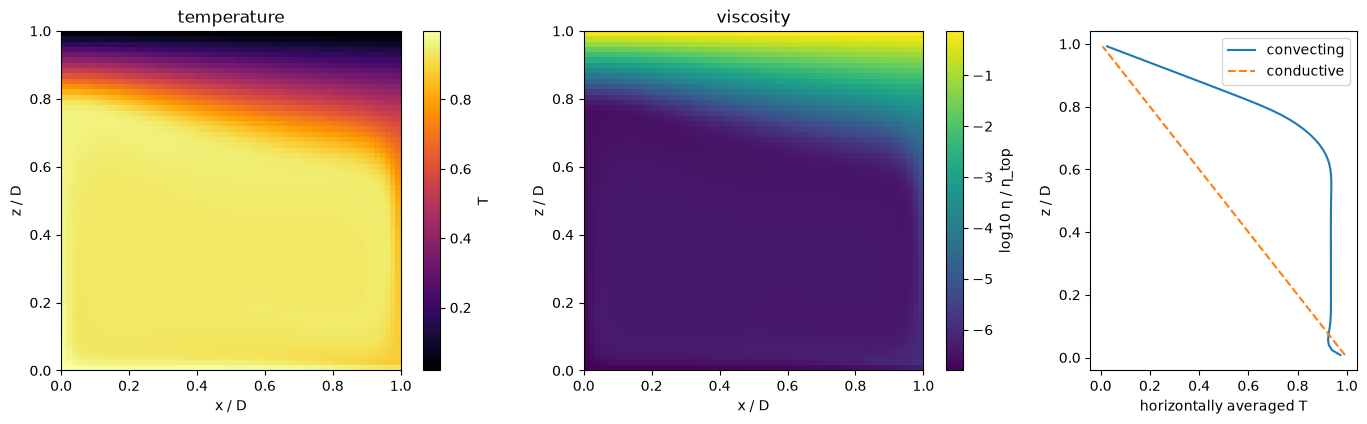

In [10]:
theta, Ra_b = 15.7, 4.6e7                      # from cell 12: q = 15 mW/m², d = 0.1 mm
Ra_top = Ra_b * np.exp(-theta)
g, T, vx, vz, iters = steady_convection(64, Ra_top, b_visc=theta, relax=0.3, max_iter=400)
eta_c, _ = viscosity(T, theta)
print(f"Ra_top = {Ra_top:.2f}, converged in {iters} iterations")
print(f"Nu = {nusselt(T, g):.3f}  (Nu = 1 would be pure conduction)")
print(f"interior temperature T_i ≈ {T[g.nz // 2].mean():.3f};  θ (1 − T_i) = {theta * (1 - T[g.nz // 2].mean()):.2f}")

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1, 0.6]})
im = ax[0].pcolormesh(g.xc, g.zc, T, cmap="inferno", shading="auto"); fig.colorbar(im, ax=ax[0], label="T")
im = ax[1].pcolormesh(g.xc, g.zc, np.log10(eta_c), cmap="viridis", shading="auto"); fig.colorbar(im, ax=ax[1], label="log10 η / η_top")
for a, t in zip(ax[:2], ("temperature", "viscosity")):
    a.set_aspect("equal"); a.set_title(t); a.set_xlabel("x / D"); a.set_ylabel("z / D")
ax[2].plot(T.mean(axis=1), g.zc, label="convecting"); ax[2].plot(1 - g.zc, g.zc, "--", label="conductive")
ax[2].set_xlabel("horizontally averaged T"); ax[2].set_ylabel("z / D"); ax[2].legend()
plt.tight_layout(); plt.show()

# Stage 2d — Real ice Ih

Two upgrades over the FK run in §13:
1. **Full Arrhenius viscosity:** η/η_b = exp[(Q/R)(1/T − 1/T_b)], Q = 59.4 kJ/mol. Between 268 K and 110 K that is a contrast of ~10¹⁶.
   A direct solver can't handle 10¹⁶, so the viscosity is **capped** at η_max. Above ~10⁸ the cold lid is rigid
   whatever its exact viscosity, so the cap shouldn't matter. We test that rather than assume it.
2. **Temperature-dependent conductivity:** k = 651/T, so cold ice conducts ~2.4× better than warm ice.
   The energy equation becomes div(vT) = div(k ∇T), with face conductivities from harmonic means.

Viscosity and conductivity are normalised to 1 at the base; Ra uses the base viscosity.
Nu is now the top heat flux divided by the flux a *conductive* shell with the same k(T) would carry.

In [11]:
def energy_steady_matrix_k(g, vx, vz, k_c, k_bot, k_top, T_bot=1.0, T_top=0.0):
    """Steady div(v T) − div(k ∇T) = 0, conductivity k_c at cell centres and k_bot/k_top at the walls.
    Face conductivity = harmonic mean of the two neighbouring cells."""
    nx, nz, dx, dz = g.nx, g.nz, g.dx, g.dz
    idx = np.arange(nx * nz).reshape(nz, nx)
    R, C, V = [], [], []
    b = np.zeros(nx * nz)
    def put(r, c, v):
        r, c, v = np.broadcast_arrays(r, c, v)
        R.append(r.ravel()); C.append(c.ravel()); V.append(np.asarray(v, float).ravel())
    J, I = np.meshgrid(np.arange(nz), np.arange(nx), indexing="ij")
    faces = [(0, +1, lambda j, i: vx[j, i + 1], +1, dx), (0, -1, lambda j, i: vx[j, i], -1, dx),
             (+1, 0, lambda j, i: vz[j + 1, i], +1, dz), (-1, 0, lambda j, i: vz[j, i], -1, dz)]
    for dj, di, face_v, sgn, h in faces:
        inner = (J + dj >= 0) & (J + dj < nz) & (I + di >= 0) & (I + di < nx)
        j, i = J[inner], I[inner]
        r, u = idx[j, i], face_v(j, i)
        kf = 2 * k_c[j, i] * k_c[j + dj, i + di] / (k_c[j, i] + k_c[j + dj, i + di])
        put(r, r, sgn * u / (2 * h) + kf / h**2)
        put(r, idx[j + dj, i + di], sgn * u / (2 * h) - kf / h**2)
    for row, T_wall, k_wall in ((0, T_bot, k_bot), (nz - 1, T_top, k_top)):
        r = idx[row]
        kh = 2 * k_c[row] * k_wall / (k_c[row] + k_wall)   # half cell between centre and wall
        put(r, r, 2 * kh / dz**2)
        b[r] += 2 * kh * T_wall / dz**2
    A = sp.csc_matrix((np.concatenate(V), (np.concatenate(R), np.concatenate(C))), shape=(nx * nz, nx * nz))
    return A, b

def corner_T(T):
    """T at cell corners: mean of the four surrounding cells (ghost-padded at the walls)."""
    Tg = T_ghost(T)
    return 0.25 * (Tg[1:, 1:] + Tg[:-1, 1:] + Tg[1:, :-1] + Tg[:-1, :-1])

def top_flux(T, g, k_c, k_top):
    """Mean conductive heat flux out of the top wall (code units)."""
    kh = 2 * k_c[-1] * k_top / (k_c[-1] + k_top)
    return np.mean(kh * T[-1] / (g.dz / 2))

def steady_convection_general(nx, nz, Ra_b, eta_fn, k_fn=None, aspect=1.0, relax=0.3, tol=1e-6,
                              max_iter=800, T0=None):
    """Steady convection: viscosity eta_fn(T) and conductivity k_fn(T), both normalised to 1 at the base (T = 1);
    Ra uses the base viscosity. Box: aspect x 1."""
    g = Grid(nx, nz, L=aspect, H=1.0)
    Xc, Zc = np.meshgrid(g.xc, g.zc)
    T = 1 - Zc + 0.1 * np.cos(np.pi * Xc / aspect) * np.sin(np.pi * Zc) if T0 is None else T0.copy()
    k_fn = k_fn or (lambda T: np.ones_like(np.asarray(T, float)))
    for it in range(1, max_iter + 1):
        A = stokes_matrix_fast(g, eta_fn(T), eta_fn(corner_T(T)))
        Tg = T_ghost(T)
        bz = -Ra_b * 0.5 * (Tg[1:, 1:-1] + Tg[:-1, 1:-1]); bz[0] = bz[-1] = 0.0
        rhs = np.zeros(A.shape[0]); rhs[g.n_vx:g.n_vx + g.n_vz] = bz.ravel()
        vx, vz, _ = unpack(g, spsolve(A, rhs))
        k_c = k_fn(T)
        Ae, be = energy_steady_matrix_k(g, vx, vz, k_c, float(k_fn(1.0)), float(k_fn(0.0)))
        T_new = spsolve(Ae, be).reshape(nz, nx)
        change = np.abs(T_new - T).max()
        T = relax * T_new + (1 - relax) * T
        if change < tol:
            return g, T, vx, vz, it, k_c
    raise RuntimeError(f"no steady state after {max_iter} iterations (last change {change:.1e})")

In [12]:
# (a) FK viscosity normalised at the base, with Ra_b, must reproduce §13 (Nu = 3.350)
theta, Ra_b = 15.7, 4.6e7
g, T, vx, vz, it, k_c = steady_convection_general(64, 64, Ra_b, lambda T: np.exp(theta * (1 - T)), tol=1e-7, max_iter=400)
print(f"(a) FK, base-normalised: Nu = {top_flux(T, g, k_c, 1.0):.4f}   (§13: 3.350)")

# (b) pure conduction (Ra = 0) with k = a/T: exact profile has ln T linear in depth
T_s, T_b = 110.0, 268.3
dT = T_b - T_s
k_ice = lambda Tp: T_b / (T_s + np.asarray(Tp) * dT)      # k / k_base for k = 651/T
g, T, _, _, _, k_c = steady_convection_general(8, 64, 0.0, lambda T: np.ones_like(T), k_ice, tol=1e-12, relax=1.0)
exact = T_b * (T_s / T_b) ** g.zc
q_cond = (T_b / dT) * np.log(T_b / T_s)                    # analytic conductive flux, code units
print(f"(b) k = a/T conduction: max |T − exact| = {np.abs(T_s + T[:, 0] * dT - exact).max():.1e} K, "
      f"flux / analytic = {top_flux(T, g, k_c, k_ice(0.0)) / q_cond:.6f}")

(a) FK, base-normalised: Nu = 3.3496   (§13: 3.350)
(b) k = a/T conduction: max |T − exact| = 2.2e-05 K, flux / analytic = 0.999984


true viscosity contrast surface/base: 4.4e+16

cap 1e+06: Nu = 1.975, interior T = 0.841   (209 iterations, 15 s)
cap 1e+08: Nu = 1.950, interior T = 0.841   (211 iterations, 15 s)
cap 1e+10: Nu = 1.949, interior T = 0.841   (211 iterations, 15 s)


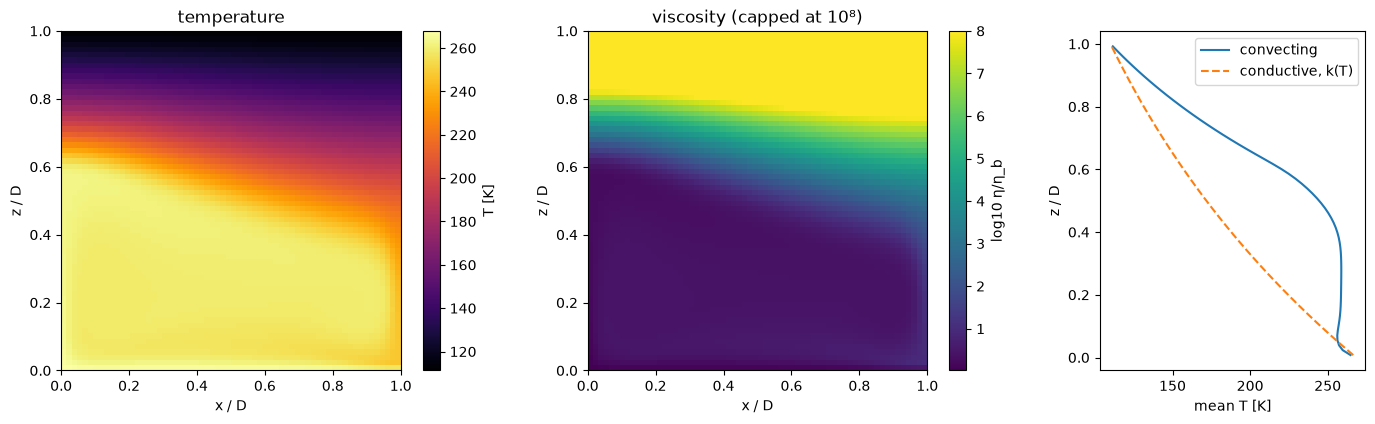

In [13]:
Q_ICE, R_GAS = 59.4e3, 8.314
def arrhenius(cap):
    return lambda Tp: np.minimum(np.exp(Q_ICE / R_GAS * (1 / (T_s + np.asarray(Tp) * dT) - 1 / T_b)), cap)

print(f"true viscosity contrast surface/base: {np.exp(Q_ICE / R_GAS * (1 / T_s - 1 / T_b)):.1e}\n")
runs = {}
for cap in (1e6, 1e8, 1e10):
    t0 = time.time()
    g, T, vx, vz, it, k_c = steady_convection_general(64, 64, Ra_b, arrhenius(cap), k_ice)
    Nu = top_flux(T, g, k_c, k_ice(0.0)) / q_cond
    runs[cap] = (g, T, vx, vz)
    print(f"cap {cap:.0e}: Nu = {Nu:.3f}, interior T = {T[g.nz // 2].mean():.3f}   ({it} iterations, {time.time()-t0:.0f} s)")

g, T, vx, vz = runs[1e8]
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1, 1, 0.6]})
im = ax[0].pcolormesh(g.xc, g.zc, T_s + T * dT, cmap="inferno", shading="auto"); fig.colorbar(im, ax=ax[0], label="T [K]")
im = ax[1].pcolormesh(g.xc, g.zc, np.log10(arrhenius(1e8)(T)), cmap="viridis", shading="auto"); fig.colorbar(im, ax=ax[1], label="log10 η/η_b")
for a, t in zip(ax[:2], ("temperature", "viscosity (capped at 10⁸)")):
    a.set_aspect("equal"); a.set_title(t); a.set_xlabel("x / D"); a.set_ylabel("z / D")
ax[2].plot(T_s + T.mean(axis=1) * dT, g.zc, label="convecting")
ax[2].plot(T_b * (T_s / T_b) ** g.zc, g.zc, "--", label="conductive, k(T)")
ax[2].set_xlabel("mean T [K]"); ax[2].set_ylabel("z / D"); ax[2].legend()
plt.tight_layout(); plt.show()

d = 0.1 mm, D =   15 km: Ra =  2.7e+06, Nu = 1.000, q_out = 38.70 mW/m²  (11 s)
d = 0.1 mm, D =   25 km: Ra =  1.2e+07, Nu = 1.504, q_out = 34.91 mW/m²  (40 s)
d = 0.1 mm, D =   39 km: Ra =  4.7e+07, Nu = 1.961, q_out = 29.18 mW/m²  (42 s)
d = 0.1 mm, D =   60 km: Ra =  1.7e+08, Nu = 2.606, q_out = 25.21 mW/m²  (44 s)
d = 0.1 mm, D =   90 km: Ra =  5.8e+08, Nu = 3.614, q_out = 23.31 mW/m²  (57 s)
d = 1.0 mm, D =   15 km: Ra =  2.7e+04, Nu = 1.000, q_out = 38.70 mW/m²  (8 s)
d = 1.0 mm, D =   25 km: Ra =  1.2e+05, Nu = 1.000, q_out = 23.22 mW/m²  (8 s)
d = 1.0 mm, D =   39 km: Ra =  4.7e+05, Nu = 1.000, q_out = 14.88 mW/m²  (8 s)
d = 1.0 mm, D =   60 km: Ra =  1.7e+06, Nu = 1.000, q_out =  9.67 mW/m²  (9 s)
d = 1.0 mm, D =   90 km: Ra =  5.8e+06, Nu = 1.388, q_out =  8.95 mW/m²  (212 s)
d = 1.0 mm, D =  130 km: Ra =  1.8e+07, Nu = 1.611, q_out =  7.19 mW/m²  (41 s)


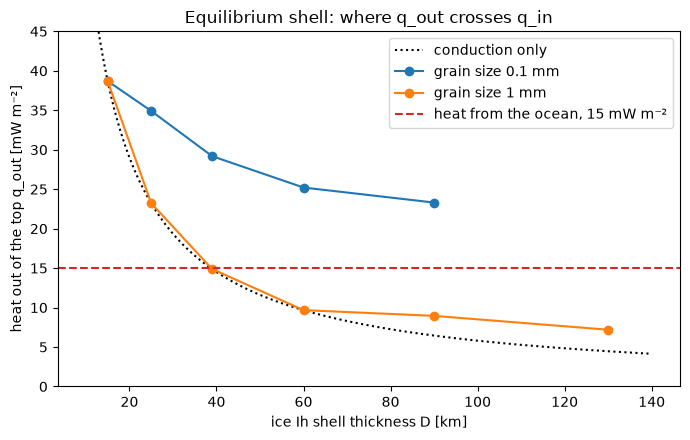

In [14]:
a_k, rho_i, alpha_i, g_s = 651.0, 920.0, 1.6e-4, 1.435
kappa_b = (a_k / T_b) / (rho_i * (7.037 * T_b + 185))
eta_base = lambda d: 8.36e9 * (T_b / 250) * d**2 * np.exp(Q_ICE / (R_GAS * T_b))
q_in = 0.015

curves = {}
for d, D_list in ((1e-4, (15e3, 25e3, 39e3, 60e3, 90e3)), (1e-3, (15e3, 25e3, 39e3, 60e3, 90e3, 130e3))):
    curves[d] = []
    for D in D_list:
        Ra = rho_i * alpha_i * g_s * dT * D**3 / (kappa_b * eta_base(d))
        t0 = time.time()
        g, T, vx, vz, it, k_c = steady_convection_general(64, 64, Ra, arrhenius(1e8), k_ice, relax=0.1, max_iter=3000)
        Nu = top_flux(T, g, k_c, k_ice(0.0)) / q_cond
        q_out = Nu * a_k * np.log(T_b / T_s) / D
        curves[d].append((D, q_out))
        print(f"d = {d*1e3:3.1f} mm, D = {D/1e3:4.0f} km: Ra = {Ra:8.1e}, Nu = {Nu:5.3f}, q_out = {q_out*1e3:5.2f} mW/m²  ({time.time()-t0:.0f} s)")

D_line = np.linspace(10e3, 140e3, 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(D_line / 1e3, a_k * np.log(T_b / T_s) / D_line * 1e3, "k:", label="conduction only")
for d, c in curves.items():
    c = np.array(c); ax.plot(c[:, 0] / 1e3, c[:, 1] * 1e3, "o-", label=f"grain size {d*1e3:g} mm")
ax.axhline(q_in * 1e3, c="tab:red", ls="--", label="heat from the ocean, 15 mW m⁻²")
ax.set_xlabel("ice Ih shell thickness D [km]"); ax.set_ylabel("heat out of the top q_out [mW m⁻²]")
ax.set_ylim(0, 45); ax.legend(); ax.set_title("Equilibrium shell: where q_out crosses q_in")
plt.tight_layout(); plt.show()

In [15]:
def top_flux2(T, g, k_top):
    """Second-order surface heat flux: k at the wall times dT/dz|wall = (8 T_wall − 9 T_N + T_{N−1}) / (3 dz), T_wall = 0."""
    return -k_top * ((-9 * T[-1] + T[-2]) / (3 * g.dz)).mean()

def convect_transient(nx, nz, Ra_b, eta_fn, k_fn, t_end, aspect=1.0, cfl=2.0, T0=None):
    """Time-dependent convection with T-dependent viscosity and conductivity.
    Each step: rebuild + solve Stokes with the current T, then one implicit (backward Euler) energy step
    (I/dt + A_e) T_new = T/dt + b_e. Implicit -> stable beyond the explicit limits; cfl sets accuracy."""
    g = Grid(nx, nz, L=aspect, H=1.0)
    Xc, Zc = np.meshgrid(g.xc, g.zc)
    T = 1 - Zc + 0.1 * np.cos(np.pi * Xc / aspect) * np.sin(np.pi * Zc) if T0 is None else T0.copy()
    I = sp.identity(nx * nz, format="csc")
    k_top, k_bot = float(k_fn(0.0)), float(k_fn(1.0))
    t, hist = 0.0, []
    while t < t_end:
        A = stokes_matrix_fast(g, eta_fn(T), eta_fn(corner_T(T)))
        Tg = T_ghost(T)
        bz = -Ra_b * 0.5 * (Tg[1:, 1:-1] + Tg[:-1, 1:-1]); bz[0] = bz[-1] = 0.0
        rhs = np.zeros(A.shape[0]); rhs[g.n_vx:g.n_vx + g.n_vz] = bz.ravel()
        vx, vz, _ = unpack(g, spsolve(A, rhs))
        dt = cfl * min(g.dx, g.dz) / max(np.abs(vx).max(), np.abs(vz).max(), 1e-12)
        Ae, be = energy_steady_matrix_k(g, vx, vz, k_fn(T), k_bot, k_top)
        T = spsolve((I / dt + Ae).tocsc(), T.ravel() / dt + be).reshape(nz, nx)
        t += dt
        hist.append((t, top_flux2(T, g, k_top), vrms(vx, vz)))
    return g, T, vx, vz, np.array(hist)

In [16]:
one = lambda T: np.ones_like(np.asarray(T, float))
t0 = time.time()
g, T, vx, vz, hist = convect_transient(32, 32, 1e4, one, one, t_end=0.6, cfl=0.5)
g2, T2, _, _, _ = steady_convection(32, 1e4)
print(f"transient: Nu = {hist[-1, 1]:.4f} after {len(hist)} steps ({time.time()-t0:.0f} s)")
print(f"steady:    Nu = {nusselt(T2, g2):.4f}")
print(f"max |T_transient − T_steady| = {np.abs(T - T2).max():.1e}")

transient: Nu = 4.9552 after 2647 steps (29 s)
steady:    Nu = 4.9552
max |T_transient − T_steady| = 3.2e-08
